In [1]:
import sys 

sys.path.append('multimae/')

from multimae.rgb_d_trainer import RgbDepthTrainer
import torch
import numpy as np
import os
import torch.nn as nn
from functools import partial
from multimae.input_adapters import PatchedInputAdapter, SemSegInputAdapter
from transforms import MultiRandomRotate, MultiHorizontalFlip, MultiVerticalFlip, DepthNormalizer, LongTransform, FirstChannelTransform
from dataset import MultiModalDataset
from torchvision import transforms
from multimae.output_adapters import DPTOutputAdapter, ConvNeXtAdapter
from multimae.multimae import multivit_base
from pos_embed_multi import interpolate_pos_embed_multimae
from pathlib import Path
from datetime import datetime
import logging
from configs.depth import depth_configs

import matplotlib.pyplot as plt
from PIL import Image


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# config = depth_configs()

# config.fine_tune_path = '../' + config.fine_tune_path
# config.val_dir = '../' + config.val_dir

multi_path = "/home/MultiModalCoreset/multimae/ckpt/multimae_40.ckpt"
coreset_path = "/home/MultiModalCoreset/multimae/ckpt/coreset_20.ckpt"
random_path = "/home/MultiModalCoreset/multimae/ckpt/random_20.ckpt"
rgb_path = "/home/MultiModalCoreset/fastapi/ckpt/rgb.ckpt"
semseg_path = "/home/MultiModalCoreset/fastapi/ckpt/semseg.ckpt"

In [3]:
train_transforms = {
    "rgb": transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Resize((224, 224)),
            transforms.Normalize(
                mean=[0.4753, 0.4713, 0.4645],
                std=[0.0903, 0.0872, 0.0869],
            ),
        ]
    ),
    "semseg": transforms.Compose(
        [
            transforms.PILToTensor(),
            transforms.Resize(
                (224, 224), interpolation=transforms.InterpolationMode.NEAREST
            ),
            FirstChannelTransform(),
            LongTransform(),
        ]
    ),
}

target_transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Resize((224, 224)), DepthNormalizer()]
)

device = 'cuda:0'
semseg_num_classes = 256

DOMAIN_CONF = {
    "rgb": {
        "channels": 3,
        "stride_level": 1,
        "input_adapter": partial(PatchedInputAdapter, num_channels=3),
        "aug_type": "image",
    },
    "depth": {
        "channels": 1,
        "stride_level": 1,
        "input_adapter": partial(PatchedInputAdapter, num_channels=1),
        "aug_type": "mask",
    },
    "mask_valid": {
        "stride_level": 1,
        "aug_type": "mask",
    },
    "semseg": {
        "stride_level": 1,
        "aug_type": "mask",
        "input_adapter": partial(
            SemSegInputAdapter,
            num_classes=semseg_num_classes,
            dim_class_emb=32,
            interpolate_class_emb=False,
            emb_padding_idx=semseg_num_classes,
        ),
    },
}

out_domains = ['depth']

patch_size = 16
input_size = 224

def init_rgb_model():


    ### SETUP DOMAIN ADAPTERS ###

    in_domains = ['rgb']
    all_domains = list(set(in_domains) | set(out_domains))

    ### INPUT ADAPTERS ###

    input_adapters = {
        domain: DOMAIN_CONF[domain]["input_adapter"](
            stride_level=DOMAIN_CONF[domain]["stride_level"],
            patch_size_full=patch_size,
            image_size=input_size,
        )
        for domain in in_domains
    }

    ### MAKE OUTPUT ADAPTERS ###

    decoder_main_tasks = ['rgb']

    additional_targets = {
        domain: DOMAIN_CONF[domain]["aug_type"] for domain in all_domains
    }

    # DPT settings are fixed for ViT-B. Modify them if using a different backbone.

    adapters_dict = {
        "dpt": DPTOutputAdapter,
        "convnext": partial(ConvNeXtAdapter, preds_per_patch=64),
    }

    output_adapter = "dpt"

    output_adapters = {
        domain: adapters_dict[output_adapter](
            num_classes=DOMAIN_CONF[domain]["channels"],
            stride_level=DOMAIN_CONF[domain]["stride_level"],
            patch_size=patch_size,
            main_tasks=decoder_main_tasks,
        )
        for domain in out_domains
    }

    ### SET MODEL ###
    model_name = "multivit_base"
    drop_path_encoder = 0.0
    model = multivit_base(
        input_adapters=input_adapters, output_adapters=output_adapters
    )


    ### LOAD CHECKPOINT ###
    finetune_path = rgb_path
    checkpoint = torch.load(finetune_path, map_location="cpu")

    checkpoint_model = checkpoint["model"]

    # Interpolate position embedding
    interpolate_pos_embed_multimae(model, checkpoint_model)

    # Load pre-trained model
    msg = model.load_state_dict(checkpoint_model, strict=False)
    print(msg)
    model.eval()

    return model


def prepare_image(img):

    x = train_transforms['rgb'](img)
    sample_dict = {'rgb': x.unsqueeze(0)}

    return sample_dict

def inference(img, model):

    sample_dict = prepare_image(img)
    
    with torch.no_grad():
        out = model(sample_dict, return_all_layers=True)

    pred = out['depth'][0][0].numpy()

    return pred
    


def init_rgb_semseg_model(path):

    ### SETUP DOMAIN ADAPTERS ###

    in_domains = ["rgb", "semseg"]
    out_domains = ["depth"]
    all_domains = list(set(in_domains) | set(out_domains))


    ### INPUT ADAPTERS ###

    input_adapters = {
        domain: DOMAIN_CONF[domain]["input_adapter"](
            stride_level=DOMAIN_CONF[domain]["stride_level"],
            patch_size_full=patch_size,
            image_size=input_size,
        )
        for domain in in_domains
    }

    ### MAKE OUTPUT ADAPTERS ###

    decoder_main_tasks = ["rgb", "semseg"]

    additional_targets = {
        domain: DOMAIN_CONF[domain]["aug_type"] for domain in all_domains
    }

    # DPT settings are fixed for ViT-B. Modify them if using a different backbone.

    adapters_dict = {
        "dpt": DPTOutputAdapter,
        "convnext": partial(ConvNeXtAdapter, preds_per_patch=64),
    }

    output_adapter = "dpt"

    output_adapters = {
        domain: adapters_dict[output_adapter](
            num_classes=DOMAIN_CONF[domain]["channels"],
            stride_level=DOMAIN_CONF[domain]["stride_level"],
            patch_size=patch_size,
            main_tasks=decoder_main_tasks,
        )
        for domain in out_domains
    }

    ### SET MODEL ###
    model_name = "multivit_base"
    drop_path_encoder = 0.0
    model = multivit_base(
        input_adapters=input_adapters, output_adapters=output_adapters
    )


    ### LOAD CHECKPOINT ###
    finetune_path = path
    checkpoint = torch.load(finetune_path, map_location="cpu")

    checkpoint_model = checkpoint["model"]

    # Interpolate position embedding
    interpolate_pos_embed_multimae(model, checkpoint_model)

    # Load pre-trained model
    msg = model.load_state_dict(checkpoint_model, strict=False)
    print(msg)
    model.eval()

    return model


def prepare_multi_image(img, semseg):

    x = train_transforms["rgb"](img)
    semseg = train_transforms["semseg"](semseg)
    sample_dict = {"rgb": x.unsqueeze(0), "semseg": semseg.unsqueeze(0)}

    return sample_dict


def multi_inference(img, semseg, model):
    sample_dict = prepare_multi_image(img, semseg)

    with torch.no_grad():
        out = model(sample_dict, return_all_layers=True)

    pred = out["depth"][0][0].numpy()

    return pred



def init_semseg_model():

    ### SETUP DOMAIN ADAPTERS ###
    in_domains = ["semseg"]
    out_domains = ["depth"]
    all_domains = list(set(in_domains) | set(out_domains))

    ### INPUT ADAPTERS ###

    input_adapters = {
        domain: DOMAIN_CONF[domain]["input_adapter"](
            stride_level=DOMAIN_CONF[domain]["stride_level"],
            patch_size_full=patch_size,
            image_size=input_size,
        )
        for domain in in_domains
    }

    ### MAKE OUTPUT ADAPTERS ###

    decoder_main_tasks = ["semseg"]

    additional_targets = {
        domain: DOMAIN_CONF[domain]["aug_type"] for domain in all_domains
    }

    # DPT settings are fixed for ViT-B. Modify them if using a different backbone.

    adapters_dict = {
        "dpt": DPTOutputAdapter,
        "convnext": partial(ConvNeXtAdapter, preds_per_patch=64),
    }

    output_adapter = "dpt"

    output_adapters = {
        domain: adapters_dict[output_adapter](
            num_classes=DOMAIN_CONF[domain]["channels"],
            stride_level=DOMAIN_CONF[domain]["stride_level"],
            patch_size=patch_size,
            main_tasks=decoder_main_tasks,
        )
        for domain in out_domains
    }

    ### SET MODEL ###
    model_name = "multivit_base"
    drop_path_encoder = 0.0
    model = multivit_base(
        input_adapters=input_adapters, output_adapters=output_adapters
    )


    ### LOAD CHECKPOINT ###
    finetune_path = semseg_path
    checkpoint = torch.load(finetune_path, map_location="cpu")

    checkpoint_model = checkpoint["model"]

    # Interpolate position embedding
    interpolate_pos_embed_multimae(model, checkpoint_model)

    # Load pre-trained model
    msg = model.load_state_dict(checkpoint_model, strict=False)
    print(msg)
    model.eval()

    return model


def prepare_semseg_image(semseg):

    semseg = train_transforms["semseg"](semseg)
    sample_dict = {"semseg": semseg.unsqueeze(0)}

    return sample_dict


def semseg_inference(semseg, model):
    sample_dict = prepare_semseg_image(semseg)

    with torch.no_grad():
        out = model(sample_dict, return_all_layers=True)

    pred = out["depth"][0][0].numpy()

    return pred

def save_predictions(pred, path):
    plt.imshow(pred)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(path)

In [4]:
multimodel = init_rgb_semseg_model(multi_path)
rand_model = init_rgb_semseg_model(random_path)
coreset_model = init_rgb_semseg_model(coreset_path)


/usr/local/lib/python3.10/dist-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


<All keys matched successfully>
<All keys matched successfully>
<All keys matched successfully>


In [5]:
model = init_rgb_model()
semseg = init_semseg_model()
multimodel = init_rgb_semseg_model()

<All keys matched successfully>
<All keys matched successfully>


TypeError: init_rgb_semseg_model() missing 1 required positional argument: 'path'

In [5]:
img = Image.open('/home/data/dq/clevr_complex/train/rgb/1003_0.png').convert('RGB')
semantic = Image.open('/home/data/dq/clevr_complex/train/semseg/1003_0.png').convert('L')
depth = Image.open('/home/data/dq/clevr_complex/train/depth/1003_0.png')

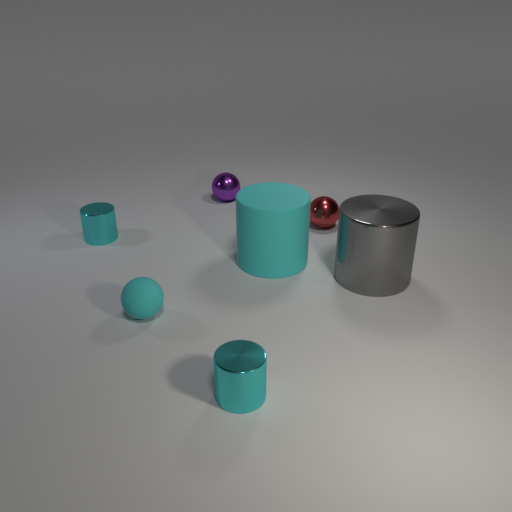

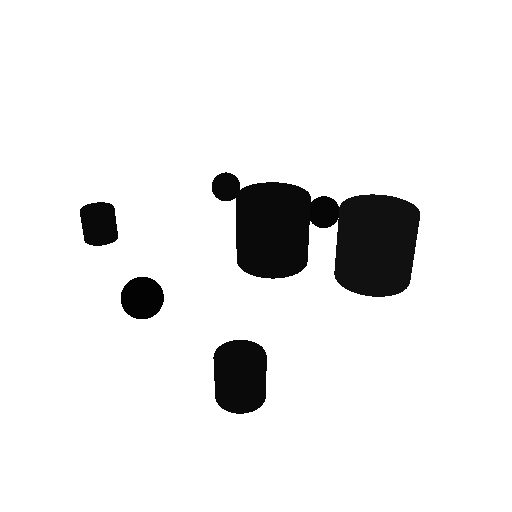

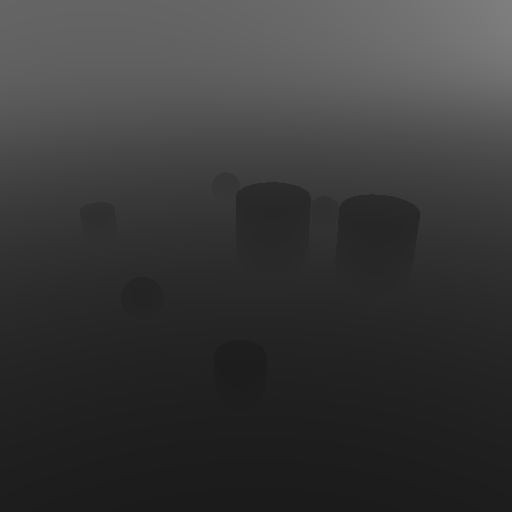

(None, None, None)

In [6]:
display(img), display(semantic), display(depth)

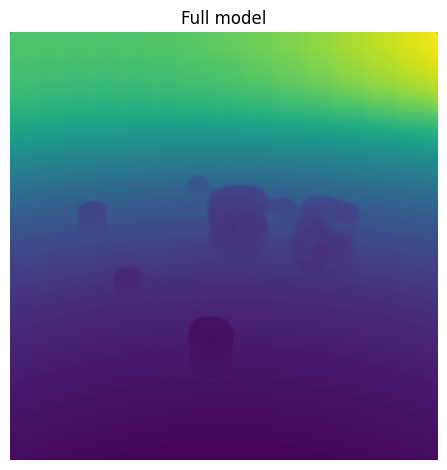

In [7]:
multi_out = multi_inference(img, semantic, multimodel)
plt.imshow(multi_out)
plt.axis('off')
plt.title('Full model')
plt.tight_layout()


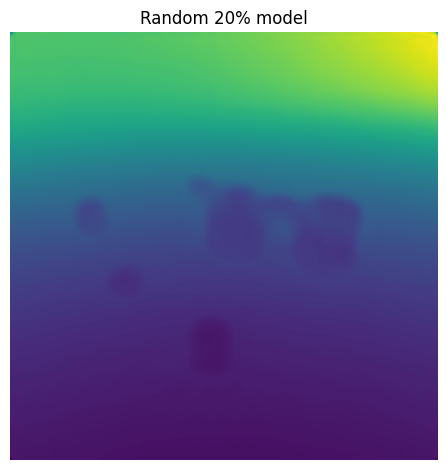

In [10]:
multi_out = multi_inference(img, semantic, rand_model)
plt.imshow(multi_out)
plt.axis('off')
plt.title('Random 20% model')
plt.tight_layout()

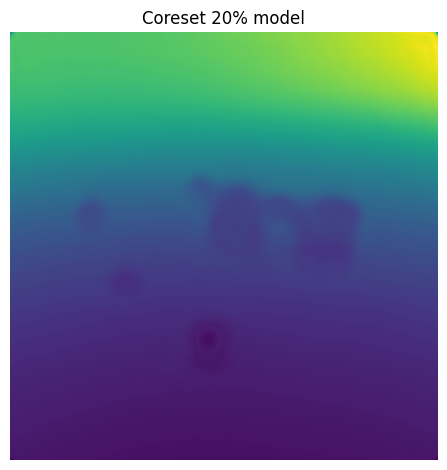

In [11]:
multi_out = multi_inference(img, semantic, coreset_model)
plt.imshow(multi_out)
plt.axis('off')
plt.title('Coreset 20% model')
plt.tight_layout()

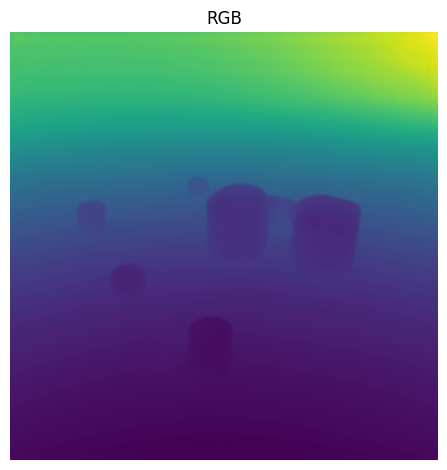

In [9]:
rgb_out = inference(img, model)
plt.imshow(rgb_out)
plt.axis('off')
plt.title('RGB')
plt.tight_layout()

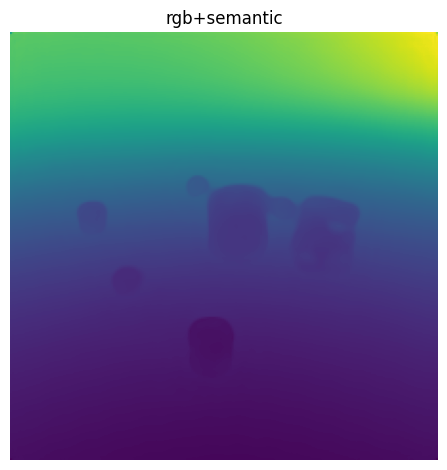

In [10]:
multi_out = multi_inference(img, semantic, multimodel)
plt.imshow(multi_out)
plt.axis('off')
plt.title('rgb+semantic')
plt.tight_layout()


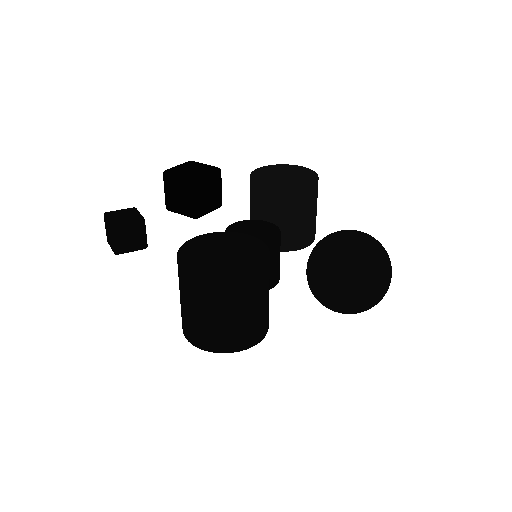

In [13]:
display(semantic)

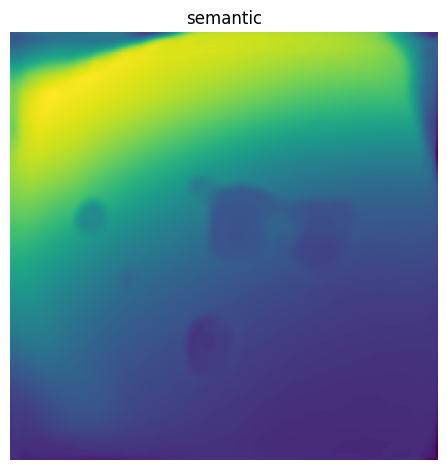

In [11]:
semseg_out = semseg_inference(semantic, semseg)
plt.imshow(semseg_out)
plt.axis('off')
plt.title('semantic')
plt.tight_layout()

In [14]:
semseg_torch = train_transforms['semseg'](semantic)

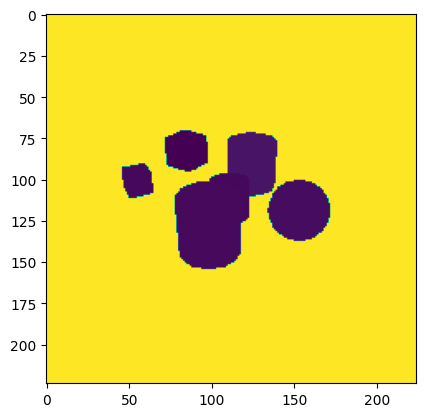

In [15]:
plt.imshow(semseg_torch.numpy())

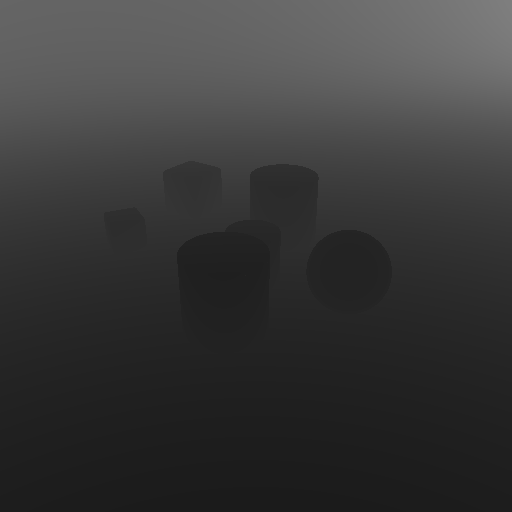

In [16]:
display(depth)

In [17]:
rotator = MultiRandomRotate(1, 90)
rotator.set_param()

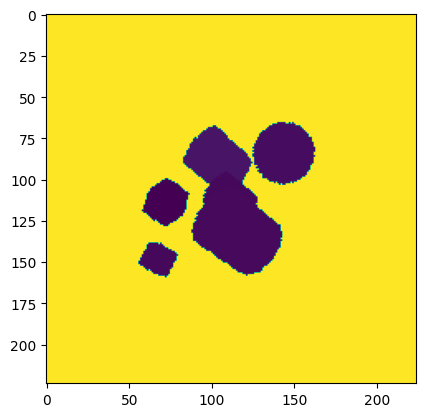

In [19]:
plt.imshow(rotator(semseg_torch, modality='semseg').numpy())

In [20]:
depth_torch = target_transform(depth)

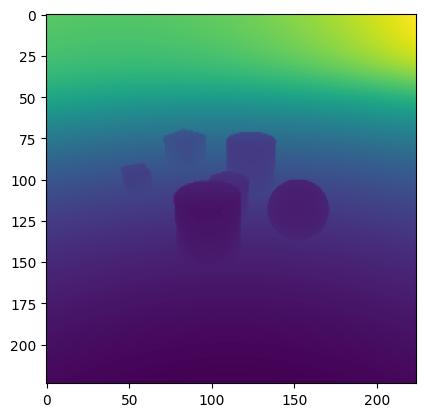

In [22]:
plt.imshow(depth_torch.numpy()[0])

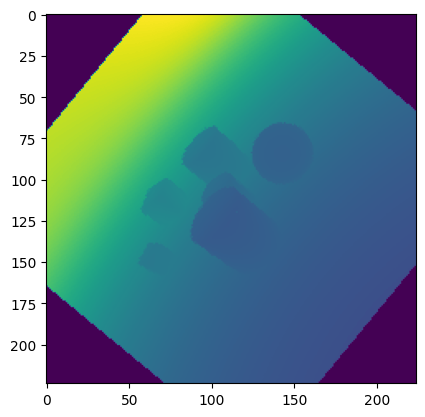

In [24]:
plt.imshow(rotator(depth_torch, modality='depth').numpy()[0])

In [27]:
@torch.no_grad()
def obtain_embeddings(model, loader, device, aggregation='none'):
    all_embeddings = []

    for i, (inp, gt) in tqdm(enumerate(loader), total=len(loader)):
        inp, gt = inp, gt.to(device)

        task_dict = {k: v.to(device) for k, v in inp.items()}

        # pred = model(
        #     task_dict, return_all_layers=True
        # ) 
        input_tokens, input_info = model.process_input(task_dict)
        encoder_tokens = model.encoder(input_tokens).cpu()
        if aggregation == 'none':
            encoder_tokens = encoder_tokens.reshape(encoder_tokens.size(0), -1).numpy()
        elif aggregation == 'sum':
            encoder_tokens = encoder_tokens.sum(dim=1).numpy()
        elif aggregation == 'mean':
            encoder_tokens = encoder_tokens.mean(dim=1).numpy()
        else:
            raise AttributeError(f'Unknown aggregation {aggregation}')
        all_embeddings.append(encoder_tokens)

    return np.vstack(all_embeddings)

In [15]:
sample_dict = prepare_multi_image(img, semantic)

In [22]:
task_dict = {k: v.to('cpu') for k, v in sample_dict.items()}
input_tokens, input_info = multimodel.process_input(task_dict)
encoder_tokens = multimodel.encoder(input_tokens).cpu()

In [29]:
emb = encoder_tokens.mean(dim=1).detach().numpy()

In [30]:
emb[0] @ emb[0].T

1908.8849

In [37]:

def cossim_np(v1, v2):
    num = np.dot(v1, v2.T)
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    res = num / denom
    if np.isneginf(res):
        res = 0.0
    return 0.5 + 0.5 * res

In [38]:
cossim_np(emb[0], emb[0])

0.9999999701976776

In [39]:
v1 = emb[0]
v2 = emb[0].T
num = np.dot(v1, v2.T)
denom = np.linalg.norm(v1) * np.linalg.norm(v2)

In [40]:
num / denom

0.99999994

In [4]:
multi_path = '/home/MultiModalCoreset/multimae/zh_ckpt/multi-exploded.ckpt'

exploded_multi = init_rgb_semseg_model()

/usr/local/lib/python3.10/dist-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


<All keys matched successfully>


In [28]:
exploded_multi is multimodel

False

In [36]:
norm_values = []
for param_name, weight in multimodel.named_parameters():
    norm_values.append(torch.norm(weight).item())
    print(param_name, torch.norm(weight))

global_tokens tensor(1.9240, grad_fn=<NormBackward1>)
input_adapters.rgb.pos_emb tensor(274.6078, grad_fn=<NormBackward1>)
input_adapters.rgb.proj.weight tensor(23.8306, grad_fn=<NormBackward1>)
input_adapters.rgb.proj.bias tensor(18.7613, grad_fn=<NormBackward1>)
input_adapters.semseg.pos_emb tensor(274.3429)
input_adapters.semseg.class_emb.weight tensor(1.8749, grad_fn=<NormBackward1>)
input_adapters.semseg.proj.weight tensor(39.2304, grad_fn=<NormBackward1>)
input_adapters.semseg.proj.bias tensor(0.1912, grad_fn=<NormBackward1>)
output_adapters.depth.scratch.layer1_rn.weight tensor(9.4819, grad_fn=<NormBackward1>)
output_adapters.depth.scratch.layer2_rn.weight tensor(9.4468, grad_fn=<NormBackward1>)
output_adapters.depth.scratch.layer3_rn.weight tensor(9.4083, grad_fn=<NormBackward1>)
output_adapters.depth.scratch.layer4_rn.weight tensor(9.4246, grad_fn=<NormBackward1>)
output_adapters.depth.scratch.refinenet1.out_conv.weight tensor(9.2176, grad_fn=<NormBackward1>)
output_adapters.d

In [37]:
torch.tensor(norm_values).mean(), torch.tensor(norm_values).std(), torch.tensor(norm_values).min(), torch.tensor(norm_values).max()

(tensor(29.3784), tensor(36.8855), tensor(0.1020), tensor(274.6078))

In [58]:
e_norm_values = []
for param_name, weight in exploded_multi.named_parameters():
    e_norm_values.append(torch.norm(weight).item())
    print(param_name, torch.norm(weight), len(np.unique(weight.detach().numpy())))

global_tokens tensor(1.9468, grad_fn=<NormBackward1>) 768
input_adapters.rgb.pos_emb tensor(274.7564, grad_fn=<NormBackward1>) 148694
input_adapters.rgb.proj.weight tensor(25.4171, grad_fn=<NormBackward1>) 587642
input_adapters.rgb.proj.bias tensor(18.7595, grad_fn=<NormBackward1>) 768
input_adapters.semseg.pos_emb tensor(274.3429) 4312
input_adapters.semseg.class_emb.weight tensor(1.8915, grad_fn=<NormBackward1>) 8221
input_adapters.semseg.proj.weight tensor(48.1574, grad_fn=<NormBackward1>) 6012703
input_adapters.semseg.proj.bias tensor(0.3560, grad_fn=<NormBackward1>) 768
output_adapters.depth.scratch.layer1_rn.weight tensor(10.6756, grad_fn=<NormBackward1>) 220794
output_adapters.depth.scratch.layer2_rn.weight tensor(11.7433, grad_fn=<NormBackward1>) 440975
output_adapters.depth.scratch.layer3_rn.weight tensor(13.9590, grad_fn=<NormBackward1>) 879042
output_adapters.depth.scratch.layer4_rn.weight tensor(16.2474, grad_fn=<NormBackward1>) 1745948
output_adapters.depth.scratch.refinen

In [7]:
x = train_transforms["rgb"](img)
semantic_t = train_transforms["semseg"](semantic)
sample_dict = {"rgb": x.unsqueeze(0), "semseg": semantic_t.unsqueeze(0)}



# def multi_inference(img, semseg, model):
# sample_dict = prepare_multi_image(img, semseg)

# with torch.no_grad():
#     out = model(sample_dict, return_all_layers=True)

In [10]:
e_out = multimodel(sample_dict, return_all_layers=True, return_embedding=True)

In [12]:
e_out['depth'].size()

torch.Size([1, 256, 112, 112])

In [15]:
with torch.no_grad():
    input_tokens, input_info = multimodel.process_input(sample_dict)
    encoder_tokens = multimodel.encoder(input_tokens)

In [21]:
encoder_tokens.reshape(encoder_tokens.size(0), -1).size()

torch.Size([1, 301824])

In [13]:
encoder_tokens.mean(), encoder_tokens.std()

(0.54013366, 20.007528)

In [56]:
exploded_multi.output_adapters.depth.head[4].weight, exploded_multi.output_adapters.depth.head[4].bias

(Parameter containing:
 tensor([[[[-8.7672e-02]],
 
          [[-2.4391e-03]],
 
          [[-1.0985e-01]],
 
          [[-4.9251e-03]],
 
          [[ 9.1095e-02]],
 
          [[ 4.6402e-02]],
 
          [[ 2.4809e-02]],
 
          [[ 1.1518e-01]],
 
          [[ 5.7780e-02]],
 
          [[-6.5554e-02]],
 
          [[ 4.2624e-03]],
 
          [[-7.4655e-02]],
 
          [[ 1.7102e-01]],
 
          [[-1.0832e-01]],
 
          [[ 3.0810e-02]],
 
          [[ 1.8296e-01]],
 
          [[-1.2591e-01]],
 
          [[-1.2267e-01]],
 
          [[ 9.3958e-02]],
 
          [[-1.2971e-01]],
 
          [[ 1.7816e-02]],
 
          [[ 1.4289e-01]],
 
          [[-1.1666e-04]],
 
          [[-2.0132e-02]],
 
          [[-2.1151e-02]],
 
          [[-2.3891e-02]],
 
          [[ 7.6193e-02]],
 
          [[-1.5743e-01]],
 
          [[ 1.6927e-02]],
 
          [[ 8.7452e-02]],
 
          [[-6.3385e-02]],
 
          [[-6.9734e-02]]]], requires_grad=True),
 Parameter containing:
 tens

In [39]:
torch.tensor(e_norm_values).mean(), torch.tensor(e_norm_values).std(), torch.tensor(e_norm_values).min(), torch.tensor(e_norm_values).max()

(tensor(30.0404), tensor(37.1378), tensor(0.1399), tensor(274.7564))

In [48]:
np.unique(multi_out) #0.27871296

array([0.27871296], dtype=float32)

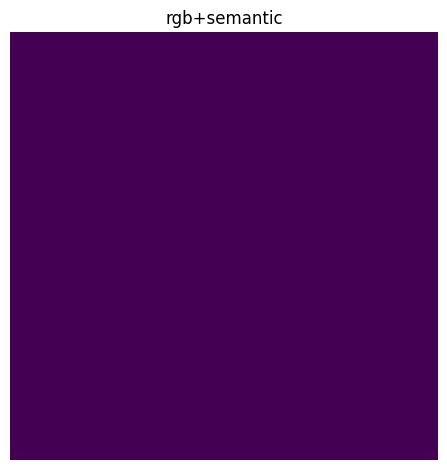

In [47]:
multi_out = multi_inference(img, semantic, exploded_multi)
plt.imshow(multi_out)
plt.axis('off')
plt.title('rgb+semantic')
plt.tight_layout()


In [9]:
sample_dict = prepare_multi_image(img, semantic)

with torch.no_grad():
    out = multimodel(sample_dict, return_all_layers=True)

In [12]:
with torch.no_grad():
    input_tokens, input_info = multimodel.process_input(sample_dict)
    encoder_tokens = multimodel.encoder(input_tokens)

In [15]:
encoder_tokens[0].size()

torch.Size([393, 768])

In [23]:

device = "cuda:0"

### SETUP DOMAIN ADAPTERS ###
semseg_num_classes = 256

DOMAIN_CONF = {
    "rgb": {
        "channels": 3,
        "stride_level": 1,
        "input_adapter": partial(PatchedInputAdapter, num_channels=3),
        "aug_type": "image",
    },
    "depth": {
        "channels": 1,
        "stride_level": 1,
        "input_adapter": partial(PatchedInputAdapter, num_channels=1),
        "aug_type": "mask",
    },
    "mask_valid": {
        "stride_level": 1,
        "aug_type": "mask",
    },
    "semseg": {
        "stride_level": 1,
        "aug_type": "mask",
        "input_adapter": partial(
            SemSegInputAdapter,
            num_classes=semseg_num_classes,
            dim_class_emb=32,
            interpolate_class_emb=False,
            emb_padding_idx=semseg_num_classes,
        ),
    },
}

in_domains = ["rgb", "semseg"]
out_domains = ["depth"]
all_domains = list(set(in_domains) | set(out_domains))

patch_size = 16
input_size = 224

### INPUT ADAPTERS ###

input_adapters = {
    domain: DOMAIN_CONF[domain]["input_adapter"](
        stride_level=DOMAIN_CONF[domain]["stride_level"],
        patch_size_full=patch_size,
        image_size=input_size,
    )
    for domain in in_domains
}

### MAKE OUTPUT ADAPTERS ###

decoder_main_tasks = ["rgb", "semseg"]

additional_targets = {
    domain: DOMAIN_CONF[domain]["aug_type"] for domain in all_domains
}

# DPT settings are fixed for ViT-B. Modify them if using a different backbone.

adapters_dict = {
    "dpt": DPTOutputAdapter,
    "convnext": partial(ConvNeXtAdapter, preds_per_patch=64),
}

output_adapter = "dpt"

output_adapters = {
    domain: adapters_dict[output_adapter](
        num_classes=DOMAIN_CONF[domain]["channels"],
        stride_level=DOMAIN_CONF[domain]["stride_level"],
        patch_size=patch_size,
        main_tasks=decoder_main_tasks,
    )
    for domain in out_domains
}

### SET MODEL ###
model_name = "multivit_base"
drop_path_encoder = 0.0
model = multivit_base(
    input_adapters=input_adapters, output_adapters=output_adapters
)

ckpt_path = "../../../data/dq/mae-b_dec512d8b_1600e_multivit-c477195b.pth"

### LOAD CHECKPOINT ###
finetune_path = ckpt_path
checkpoint = torch.load(finetune_path, map_location="cpu")

checkpoint_model = checkpoint["model"]

# Interpolate position embedding
interpolate_pos_embed_multimae(model, checkpoint_model)

# Load pre-trained model
msg = model.load_state_dict(checkpoint_model, strict=False)
print(msg)
model.eval()



_IncompatibleKeys(missing_keys=['input_adapters.semseg.pos_emb', 'input_adapters.semseg.class_emb.weight', 'input_adapters.semseg.proj.weight', 'input_adapters.semseg.proj.bias', 'output_adapters.depth.scratch.layer1_rn.weight', 'output_adapters.depth.scratch.layer2_rn.weight', 'output_adapters.depth.scratch.layer3_rn.weight', 'output_adapters.depth.scratch.layer4_rn.weight', 'output_adapters.depth.scratch.layer_rn.0.weight', 'output_adapters.depth.scratch.layer_rn.1.weight', 'output_adapters.depth.scratch.layer_rn.2.weight', 'output_adapters.depth.scratch.layer_rn.3.weight', 'output_adapters.depth.scratch.refinenet1.out_conv.weight', 'output_adapters.depth.scratch.refinenet1.out_conv.bias', 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv1.weight', 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv1.bias', 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv2.weight', 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv2.bias', 'output_adapters.depth.

MultiViT(
  (input_adapters): ModuleDict(
    (rgb): PatchedInputAdapter(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (semseg): SemSegInputAdapter(
      (class_emb): Embedding(257, 32, padding_idx=256)
      (proj): Conv2d(32, 768, kernel_size=(16, 16), stride=(16, 16))
    )
  )
  (output_adapters): ModuleDict(
    (depth): DPTOutputAdapter(
      (scratch): Module(
        (layer1_rn): Conv2d(96, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (layer2_rn): Conv2d(192, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (layer3_rn): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (layer4_rn): Conv2d(768, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (layer_rn): ModuleList(
          (0): Conv2d(96, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): Conv2d(192, 256, kernel_size=(3, 3), stride=(1, 1),

In [25]:
msg.missing_keys

['input_adapters.semseg.pos_emb',
 'input_adapters.semseg.class_emb.weight',
 'input_adapters.semseg.proj.weight',
 'input_adapters.semseg.proj.bias',
 'output_adapters.depth.scratch.layer1_rn.weight',
 'output_adapters.depth.scratch.layer2_rn.weight',
 'output_adapters.depth.scratch.layer3_rn.weight',
 'output_adapters.depth.scratch.layer4_rn.weight',
 'output_adapters.depth.scratch.layer_rn.0.weight',
 'output_adapters.depth.scratch.layer_rn.1.weight',
 'output_adapters.depth.scratch.layer_rn.2.weight',
 'output_adapters.depth.scratch.layer_rn.3.weight',
 'output_adapters.depth.scratch.refinenet1.out_conv.weight',
 'output_adapters.depth.scratch.refinenet1.out_conv.bias',
 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv1.weight',
 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv1.bias',
 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv2.weight',
 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv2.bias',
 'output_adapters.depth.scratch.refin

In [70]:
uniqs, counts = np.unique(gold, return_counts=True)

In [78]:
flattened_image = gold.flatten()

# Step 3: Count the frequency of each pixel value
pixel_values, counts = np.unique(flattened_image, return_counts=True)


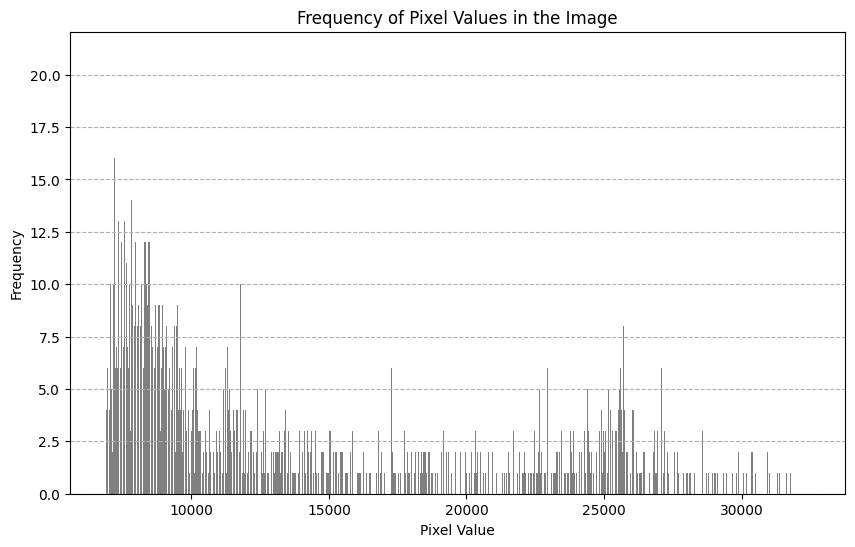

In [79]:

# Step 4: Plot the frequency of each pixel value
plt.figure(figsize=(10, 6))
plt.bar(pixel_values, counts, color='gray')
plt.title('Frequency of Pixel Values in the Image')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
#plt.xlim(0, 255) # Pixel values range from 0 to 255
plt.grid(axis='y', linestyle='--')
plt.show()

In [67]:
np.histogram(np.ravel(gold))

(array([19444,  7392,  4268,  2917,  2817,  2593,  3602,  4859,  1611,
          673]),
 array([ 6870. ,  9431.2, 11992.4, 14553.6, 17114.8, 19676. , 22237.2,
        24798.4, 27359.6, 29920.8, 32482. ]))

In [53]:
rgb_err = abs(rgb_out - gold)
multi_err = abs(multi_out - gold)

In [60]:
rgb_err.mean(), multi_err.mean(), rgb_err.sum() > multi_err.sum()

(286.6300665505078, 279.0759788143391, True)

In [61]:
rgb_err

array([[   2.4609375 ,  863.421875  ,  508.49609375, ...,  666.24609375,
         690.23828125,  635.76367188],
       [ 424.95117188,  632.9453125 ,  751.99609375, ...,  712.8828125 ,
         439.48828125,  212.43359375],
       [ 254.97070312,  543.34375   ,  516.07421875, ...,  606.3046875 ,
         509.49609375,  179.7109375 ],
       ...,
       [ 342.21142578,  162.11425781,  214.70214844, ...,  117.73828125,
          20.73681641,   48.79492188],
       [ 311.58447266,  463.90380859,  449.90625   , ...,  120.72558594,
         220.54736328,  157.65625   ],
       [1101.77001953,   74.42285156,  605.11474609, ...,  371.97460938,
         130.44482422,  903.53808594]])

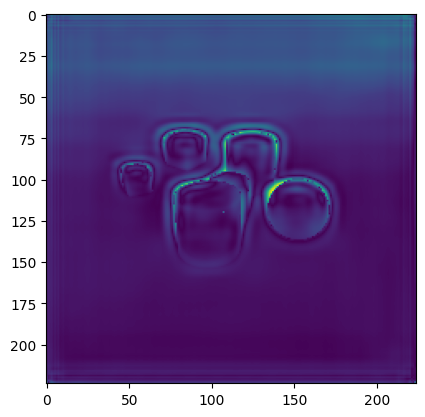

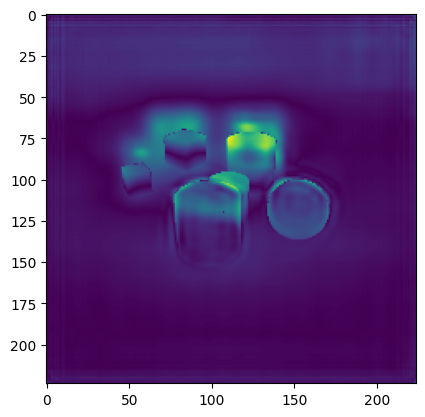

In [59]:
plt.imshow(rgb_err)
plt.show()
plt.imshow(multi_err)

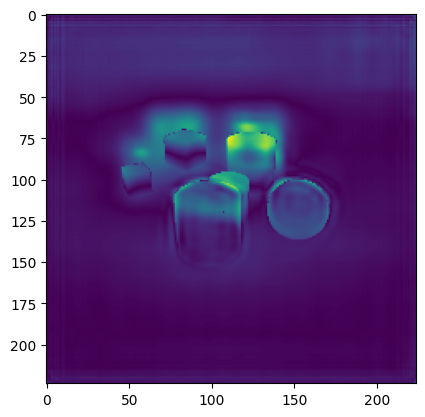

In [6]:
### MAKE TRANSFORMS ###

train_transforms = {
    "rgb": transforms.Compose(
        [transforms.ToTensor(), transforms.Resize((224, 224))]
    ),
    "semseg": transforms.Compose(
        [
            transforms.PILToTensor(),
            transforms.Resize((224, 224)),
            FirstChannelTransform(),
            LongTransform(),
        ]
    ),
}
target_transform = transforms.Compose(
    [transforms.PILToTensor(), transforms.Resize((224, 224))]
)

### MAKE DATASETS ###

val_dataset = MultiModalDataset(
    root_dir=config.val_dir,
    input_tasks=in_domains,
    output_task=out_domains[0],
    train_transform=train_transforms,
    target_transofrm=target_transform,
)


In [7]:
sample_dict, target = val_dataset[0]

In [8]:
for k, v in sample_dict.items():
    sample_dict[k] = v.unsqueeze(0)

In [9]:
out = model(sample_dict, return_all_layers=True)

In [90]:
pred = out['depth'][0][0].detach()

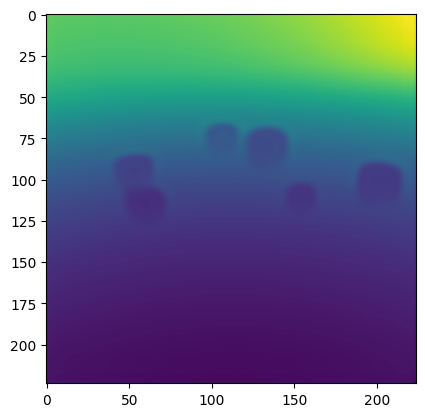

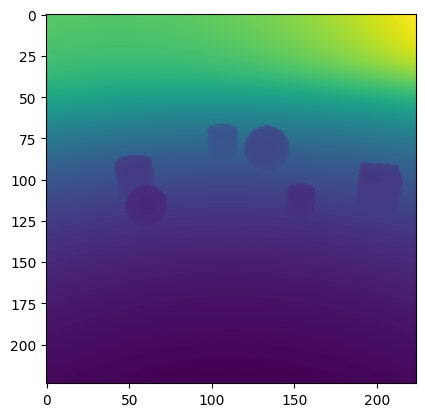

In [10]:
for i in range(1):
    sample_dict, target = val_dataset[i]
    for k, v in sample_dict.items():
        sample_dict[k] = v.unsqueeze(0)
    
    with torch.no_grad():
        out = model(sample_dict, return_all_layers=True)
    pred = out['depth'][0][0].detach()
    target = target[0]
    plt.imshow(pred.numpy())
    plt.show()
    plt.imshow(target.numpy())
    plt.show()

In [11]:
np.save('test.npy', target.numpy())

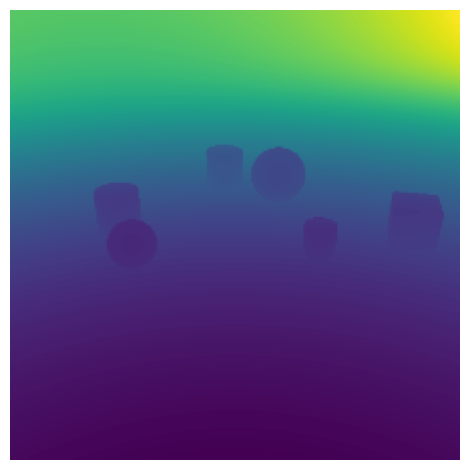

In [17]:
plt.imshow(target.numpy())
plt.axis('off')
plt.tight_layout()
plt.savefig('test.jpg')

In [50]:
notr_dataset = MultiModalDataset(
    root_dir=config.val_dir,
    input_tasks=in_domains,
    output_task=out_domains[0],
    train_transform=train_transforms,
    target_transofrm=None,
)

In [60]:
d, t = notr_dataset[0]

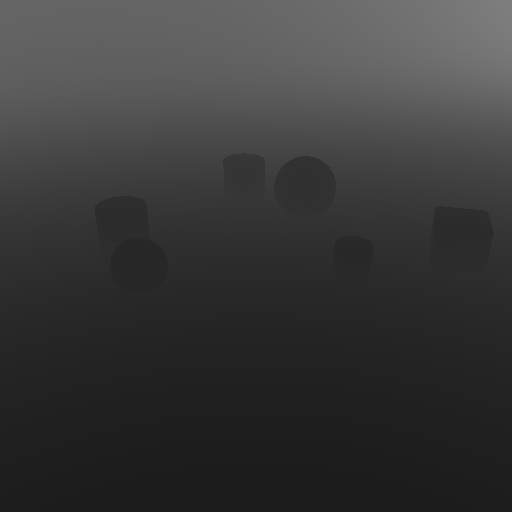

In [62]:
t.convert('L')
t

In [71]:
np.array(t).shape

(512, 512)

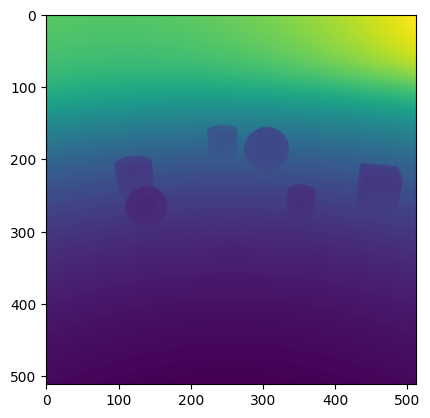

In [56]:
plt.imshow(np.array(t))

In [2]:
x = torch.rand(10, 393*768)

In [6]:
x.element_size() * x.nelement() * (60000/10) / (1024 * 1024 * 1024)

67.46292114257812

In [8]:
x.numpy().shape[0]

10

In [9]:
import pickle

In [10]:
with open('/home/data/dq/clevr_complex/val/sampled_idx.pickle', 'rb') as f:
    ls = pickle.load(f)

In [11]:
ls

[3701,
 4739,
 426,
 3506,
 3238,
 4197,
 2993,
 1899,
 3025,
 266,
 3964,
 3900,
 302,
 905,
 1258,
 3733,
 3735,
 4523,
 122,
 1337,
 3087,
 1850,
 683,
 3312,
 2437,
 3295,
 1004,
 599,
 1313,
 1110,
 3802,
 2983,
 3141,
 790,
 3965,
 1037,
 3206,
 551,
 3846,
 1595,
 977,
 2591,
 2016,
 4581,
 2738,
 4344,
 1022,
 1522,
 3496,
 725,
 1591,
 3633,
 2610,
 3067,
 2916,
 1483,
 1321,
 1890,
 4667,
 2760,
 788,
 189,
 3862,
 1412,
 1500,
 4740,
 4463,
 3010,
 4251,
 3200,
 115,
 2207,
 2236,
 2754,
 3635,
 1241,
 4385,
 4392,
 4665,
 1242,
 1495,
 4975,
 3696,
 226,
 2240,
 84,
 4191,
 4941,
 60,
 833,
 3809,
 2280,
 4995,
 2900,
 2804,
 2507,
 996,
 2096,
 4654,
 2409,
 3356,
 4935,
 4437,
 953,
 3700,
 3851,
 378,
 646,
 4261,
 929,
 1119,
 4479,
 3285,
 3053,
 4758,
 3266,
 4041,
 3197,
 3858,
 1664,
 2146,
 3088,
 523,
 2387,
 3654,
 670,
 3776,
 501,
 2265,
 3547,
 2896,
 1234,
 617,
 4327,
 1655,
 2085,
 1390,
 914,
 868,
 4627,
 2774,
 610,
 1718,
 2313,
 4857,
 1905,
 2963,
 26